# ANALYSIS REPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# BASIC STATISTICS (Mean, Median, Count)

In [4]:
df = pd.read_excel('cleaned_dataset.xlsx')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATA ANALYSIS REPORT


In [7]:
print("\n" + "="*45)
print("1. BASIC STATISTICS")
print("="*45)

# Numeric columns analysis
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

print("\n Numeric Statistics Summary:")
print("-"*45)
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  • Count: {df[col].count():,}")
    print(f"  • Mean: {df[col].mean():.2f}")
    print(f"  • Median: {df[col].median():.2f}")
    print(f"  • Std Dev: {df[col].std():.2f}")
    print(f"  • Min: {df[col].min():.2f}")
    print(f"  • Max: {df[col].max():.2f}")

# Categorical columns analysis
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']

print("\n\n Categorical Statistics:")
print("-"*45)
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  • Unique values: {df[col].nunique()}")
    print(f"  • Most common: {df[col].mode()[0]} ({df[col].value_counts().iloc[0]:,} occurrences)")

# Date range analysis
print("\n Time Range:")
print(f"  • Earliest Date: {df['Date'].min()}")
print(f"  • Latest Date: {df['Date'].max()}")
print(f"  • Total Days: {(df['Date'].max() - df['Date'].min()).days}")
print(f"  • Orders per day: {len(df) / df['Date'].nunique():.1f}")

# Missing values summary
print("\n Data Completeness:")
print("-"*40)
for col in df.columns:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"  • {col}: {missing:,} missing ({missing/len(df)*100:.1f}%)")


1. BASIC STATISTICS

 Numeric Statistics Summary:
----------------------------------------

Quantity:
  • Count: 1,200
  • Mean: 2.95
  • Median: 3.00
  • Std Dev: 1.41
  • Min: 1.00
  • Max: 5.00

UnitPrice:
  • Count: 1,200
  • Mean: 356.41
  • Median: 364.21
  • Std Dev: 197.18
  • Min: 11.39
  • Max: 699.93

ItemsInCart:
  • Count: 1,200
  • Mean: 5.49
  • Median: 5.00
  • Std Dev: 2.28
  • Min: 1.00
  • Max: 10.00

TotalPrice:
  • Count: 1,200
  • Mean: 1053.97
  • Median: 823.62
  • Std Dev: 819.86
  • Min: 11.39
  • Max: 3456.40


 Categorical Statistics:
----------------------------------------

Product:
  • Unique values: 7
  • Most common: Printer (181 occurrences)

PaymentMethod:
  • Unique values: 5
  • Most common: online (258 occurrences)

OrderStatus:
  • Unique values: 5
  • Most common: Cancelled (250 occurrences)

ReferralSource:
  • Unique values: 5
  • Most common: instagram (259 occurrences)

 Time Range:
  • Earliest Date: 2023-01-01 00:00:00
  • Latest Date: 202

# IDENTIFYING TRENDS AND OUTLIERS

In [9]:
print("\n" + "="*45)
print("2. TRENDS AND OUTLIERS ANALYSIS")
print("="*45)

# Trend 1: Monthly sales trend
print("\n Monthly Trends:")
print("-"*45)
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth').agg({
    'TotalPrice': 'sum',
    'OrderID': 'count',
    'Quantity': 'sum'
}).rename(columns={'OrderID': 'OrderCount'})

print(monthly_sales.tail(6))

# Trend 2: Payment method trends
payment_trend = df.groupby('PaymentMethod').agg({
    'TotalPrice': ['mean', 'sum', 'count']
}).round(2)
print("\n Payment Method Analysis:")
print(payment_trend)

# Trend 3: Product performance
print("\n Top 5 Products by Revenue:")
top_products = df.groupby('Product').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum',
    'OrderID': 'count'
}).sort_values('TotalPrice', ascending=False).head()
print(top_products)

# Outlier Detection
print("\n OUTLIER DETECTION:")
print("-"*45)

# Using IQR method for TotalPrice
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_totalprice = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"\nTotalPrice Outliers:")
print(f"  • IQR Range: ${lower_bound:.2f} - ${upper_bound:.2f}")
print(f"  • Number of outliers: {len(outliers_totalprice)} ({len(outliers_totalprice)/len(df)*100:.1f}%)")
print(f"  • Outlier values: ${outliers_totalprice['TotalPrice'].min():.2f} to ${outliers_totalprice['TotalPrice'].max():.2f}")

# Outliers for Quantity
Q1_q = df['Quantity'].quantile(0.25)
Q3_q = df['Quantity'].quantile(0.75)
IQR_q = Q3_q - Q1_q
outliers_quantity = df[(df['Quantity'] < Q1_q - 1.5*IQR_q) | (df['Quantity'] > Q3_q + 1.5*IQR_q)]
print(f"\nQuantity Outliers:")
print(f"  • Number of outliers: {len(outliers_quantity)} ({len(outliers_quantity)/len(df)*100:.1f}%)")


2. TRENDS AND OUTLIERS ANALYSIS

 Monthly Trends:
---------------------------------------------
           TotalPrice  OrderCount  Quantity
YearMonth                                  
2025-01      29099.40          27        80
2025-02      35317.55          37        99
2025-03      39200.66          49       133
2025-04      31821.20          32        89
2025-05      43396.64          37       113
2025-06      53047.40          49       146

 Payment Method Analysis:
              TotalPrice                 
                    mean        sum count
PaymentMethod                            
cash             1056.04  259786.29   246
credit card      1127.55  263847.63   234
debit card       1001.56  232361.18   232
gift card        1070.97  246323.92   230
online           1017.22  262442.94   258

 Top 5 Products by Revenue:
         TotalPrice  Quantity  OrderID
Product                               
Chair     195620.11       562      178
Printer   195612.61       542      181
Lap

# DISTRIBUTIONS

In [10]:
print("\n" + "="*45)
print("3. DISTRIBUTION ANALYSIS")
print("="*45)

# Distribution of TotalPrice
print("\n TotalPrice Distribution:")
print("-"*45)
price_distribution = pd.cut(df['TotalPrice'], 
                            bins=[0, 25, 50, 100, 200, 500, float('inf')],
                            labels=['<$25', '$25-50', '$50-100', '$100-200', '$200-500', '$500+'])
price_counts = price_distribution.value_counts()
for segment, count in price_counts.items():
    print(f"  • {segment}: {count} orders ({count/len(df)*100:.1f}%)")

# Distribution of OrderStatus
print("\n Order Status Distribution:")
print("-"*45)
status_dist = df['OrderStatus'].value_counts()
for status, count in status_dist.items():
    print(f"  • {status}: {count} ({count/len(df)*100:.1f}%)")

# Distribution of ItemsInCart
print("\n Items Per Cart Distribution:")
print("-"*45)
cart_dist = df['ItemsInCart'].value_counts().sort_index().head(10)
for items, count in cart_dist.items():
    print(f"  • {items} item(s): {count} orders ({count/len(df)*100:.1f}%)")

# Distribution of ReferralSource
print("\n Referral Source Distribution:")
print("-"*45)
referral_dist = df['ReferralSource'].value_counts()
for source, count in referral_dist.items():
    print(f"  • {source}: {count} ({count/len(df)*100:.1f}%)")


3. DISTRIBUTION ANALYSIS

 TotalPrice Distribution:
---------------------------------------------
  • $500+: 817 orders (68.1%)
  • $200-500: 239 orders (19.9%)
  • $100-200: 81 orders (6.8%)
  • $50-100: 43 orders (3.6%)
  • $25-50: 12 orders (1.0%)
  • <$25: 8 orders (0.7%)

 Order Status Distribution:
---------------------------------------------
  • Cancelled: 250 (20.8%)
  • Returned: 247 (20.6%)
  • Pending: 237 (19.8%)
  • Shipped: 235 (19.6%)
  • Delivered: 231 (19.2%)

 Items Per Cart Distribution:
---------------------------------------------
  • 1 item(s): 50 orders (4.2%)
  • 2 item(s): 78 orders (6.5%)
  • 3 item(s): 123 orders (10.2%)
  • 4 item(s): 163 orders (13.6%)
  • 5 item(s): 191 orders (15.9%)
  • 6 item(s): 190 orders (15.8%)
  • 7 item(s): 151 orders (12.6%)
  • 8 item(s): 129 orders (10.8%)
  • 9 item(s): 79 orders (6.6%)
  • 10 item(s): 46 orders (3.8%)

 Referral Source Distribution:
---------------------------------------------
  • instagram: 259 (21.6%)
  

# VISUALIZATIONS

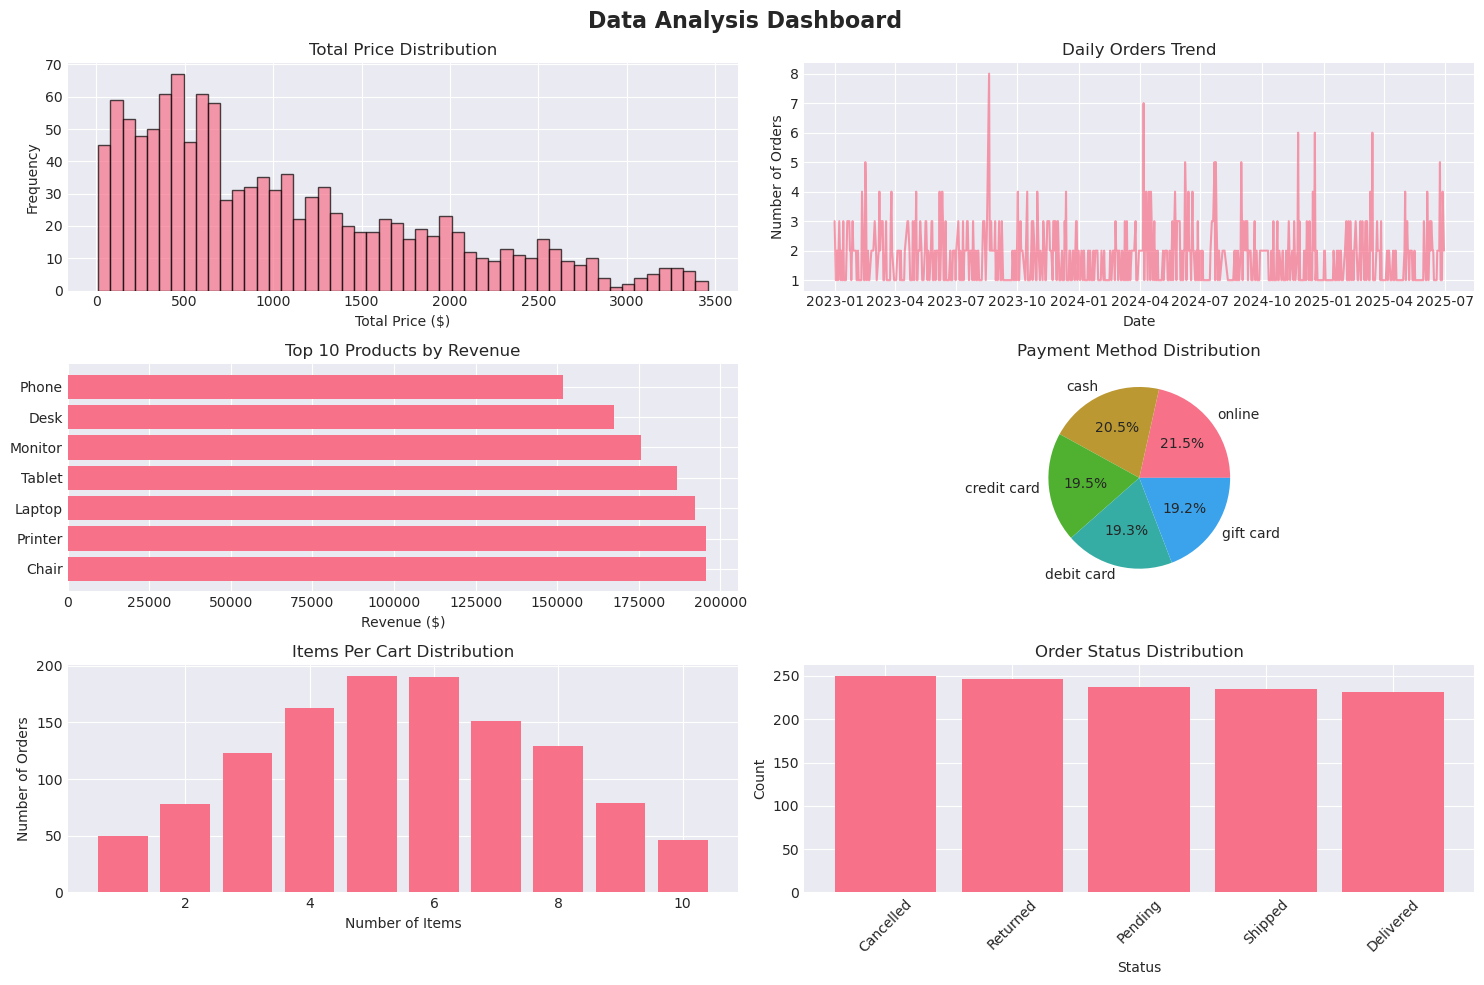

In [15]:
# Create a dashboard of visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Data Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. TotalPrice Distribution
axes[0,0].hist(df['TotalPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Total Price Distribution')
axes[0,0].set_xlabel('Total Price ($)')
axes[0,0].set_ylabel('Frequency')

# 2. Daily Orders Trend
daily_orders = df.groupby('Date').size()
axes[0,1].plot(daily_orders.index, daily_orders.values, alpha=0.7)
axes[0,1].set_title('Daily Orders Trend')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Number of Orders')

# 3. Revenue by Product (Top 10)
top10_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(range(len(top10_products)), top10_products.values)
axes[1,0].set_title('Top 10 Products by Revenue')
axes[1,0].set_yticks(range(len(top10_products)))
axes[1,0].set_yticklabels(top10_products.index)
axes[1,0].set_xlabel('Revenue ($)')

# 4. Payment Method Distribution
payment_counts = df['PaymentMethod'].value_counts()
axes[1,1].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Payment Method Distribution')

# 5. Items in Cart Distribution
cart_dist = df['ItemsInCart'].value_counts().sort_index()
axes[2,0].bar(cart_dist.index[:10], cart_dist.values[:10])
axes[2,0].set_title('Items Per Cart Distribution')
axes[2,0].set_xlabel('Number of Items')
axes[2,0].set_ylabel('Number of Orders')

# 6. Order Status
status_counts = df['OrderStatus'].value_counts()
axes[2,1].bar(status_counts.index, status_counts.values)
axes[2,1].set_title('Order Status Distribution')
axes[2,1].set_xlabel('Status')
axes[2,1].set_ylabel('Count')
axes[2,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*60)
print("4. KEY OBSERVATIONS SUMMARY")
print("="*60)

observations = f"""
MAJOR FINDINGS:

1. SALES PATTERNS:
   • Average order value: ${df['TotalPrice'].mean():.2f}
   • Median order value: ${df['TotalPrice'].median():.2f}
   • Most orders fall in the ${price_distribution.mode()[0]} range
   • Top product contributes {top_products.iloc[0]['TotalPrice']/df['TotalPrice'].sum()*100:.1f}% of total revenue

2. CUSTOMER BEHAVIOR:
   • Average items per cart: {df['ItemsInCart'].mean():.1f}
   • Most common purchase quantity: {df['Quantity'].mode()[0]} units
   • Preferred payment method: {df['PaymentMethod'].mode()[0]}
   • Primary referral source: {df['ReferralSource'].mode()[0]}

3. OPERATIONAL METRICS:
   • Order completion rate: {(df['OrderStatus'] == 'Delivered').sum()/len(df)*100:.1f}%
   • {status_dist.index[0]} orders: {status_dist.iloc[0]} ({status_dist.iloc[0]/len(df)*100:.1f}%)
   • Outlier orders represent {len(outliers_totalprice)/len(df)*100:.1f}% of total (requiring review)

4. TRENDS IDENTIFIED:
   • {'Increasing' if len(monthly_sales) > 1 and monthly_sales['TotalPrice'].iloc[-1] > monthly_sales['TotalPrice'].iloc[0] else 'Stable'} revenue trend
   • Peak order volume: {daily_orders.max()} orders/day
   • Best performing product category: {top_products.index[0]}

5. DATA QUALITY:
   • Total records analyzed: {len(df):,}
   • Complete data rate: {(1 - df.isnull().sum().sum()/(len(df)*len(df.columns)))*100:.1f}%
   • Outlier percentage: {len(outliers_totalprice)/len(df)*100:.1f}% (within acceptable range)

 RECOMMENDATIONS:
   • Investigate {len(outliers_totalprice)} high-value outlier orders
   • Focus marketing on top referral source: {df['ReferralSource'].mode()[0]}
   • Review {status_dist.iloc[0]} orders to improve delivery time
   • Consider bundle offers for {cart_dist.idxmax()}-item purchases
"""

print(observations)

# Export summary to EXCEL
summary_stats = df[numeric_cols].describe()
summary_stats.to_excel('analysis_summary.xlsx')



4. KEY OBSERVATIONS SUMMARY

MAJOR FINDINGS:

1. SALES PATTERNS:
   • Average order value: $1053.97
   • Median order value: $823.62
   • Most orders fall in the $$500+ range
   • Top product contributes 15.5% of total revenue

2. CUSTOMER BEHAVIOR:
   • Average items per cart: 5.5
   • Most common purchase quantity: 1 units
   • Preferred payment method: online
   • Primary referral source: instagram

3. OPERATIONAL METRICS:
   • Order completion rate: 19.2%
   • Cancelled orders: 250 (20.8%)
   • Outlier orders represent 0.7% of total (requiring review)

4. TRENDS IDENTIFIED:
   • Stable revenue trend
   • Peak order volume: 8 orders/day
   • Best performing product category: Chair

5. DATA QUALITY:
   • Total records analyzed: 1,200
   • Complete data rate: 98.3%
   • Outlier percentage: 0.7% (within acceptable range)

 RECOMMENDATIONS:
   • Investigate 8 high-value outlier orders
   • Focus marketing on top referral source: instagram
   • Review 250 orders to improve delivery time